ASSOCIATION RULE MINING - FOOD INSPECTION DATA
✓ Cleaned data loaded: 264,709 rows × 17 columns

--------------------------------------------------------------------------------
1. PREPARING VIOLATION TERMS TRANSACTIONS
--------------------------------------------------------------------------------
Records with violations: 192,361 (72.7%)
Unique violation terms: 65

Top 10 most frequent individual violation terms:
   1. V_34    : 70,168 ( 36.5%)
   2. V_38    : 65,506 ( 34.1%)
   3. V_33    : 64,505 ( 33.5%)
   4. V_35    : 63,862 ( 33.2%)
   5. V_32    : 53,016 ( 27.6%)
   6. V_55    : 38,205 ( 19.9%)
   7. V_41    : 37,851 ( 19.7%)
   8. V_36    : 32,421 ( 16.9%)
   9. V_3     : 25,789 ( 13.4%)
  10. V_47    : 19,985 ( 10.4%)
Total transactions for violation analysis: 192,361

--------------------------------------------------------------------------------
APRIORI ANALYSIS: Violation Terms Combinations
--------------------------------------------------------------------------------


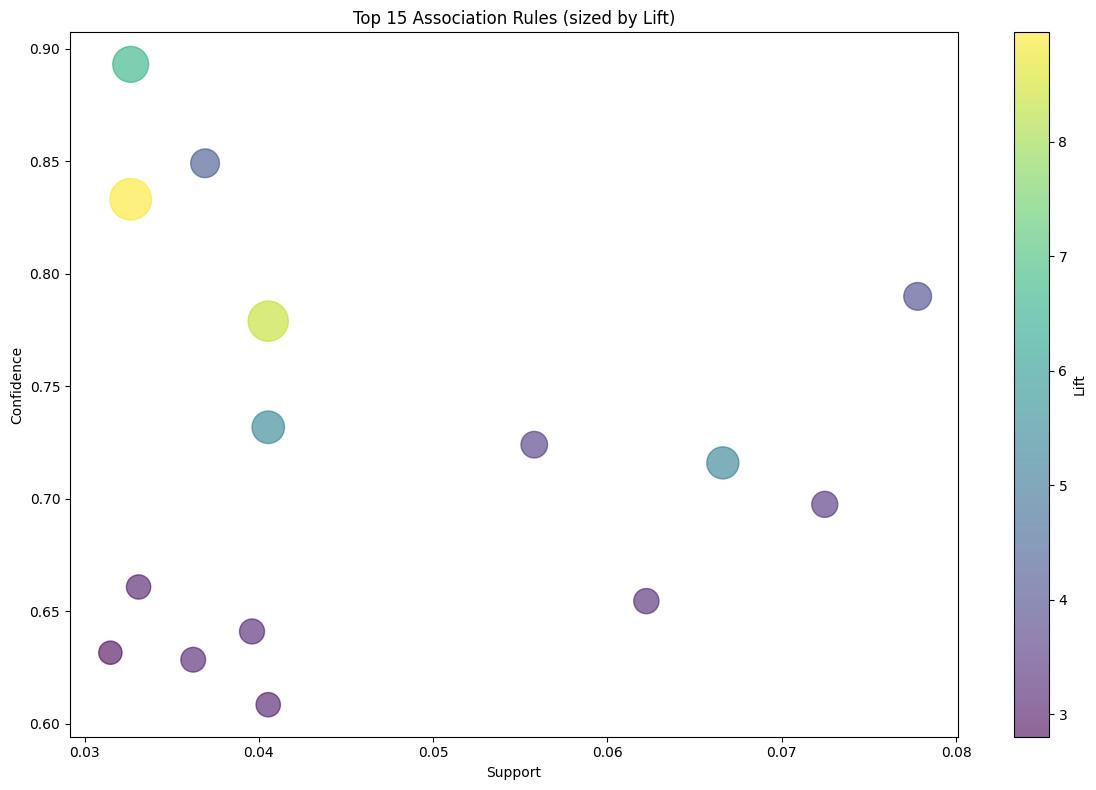

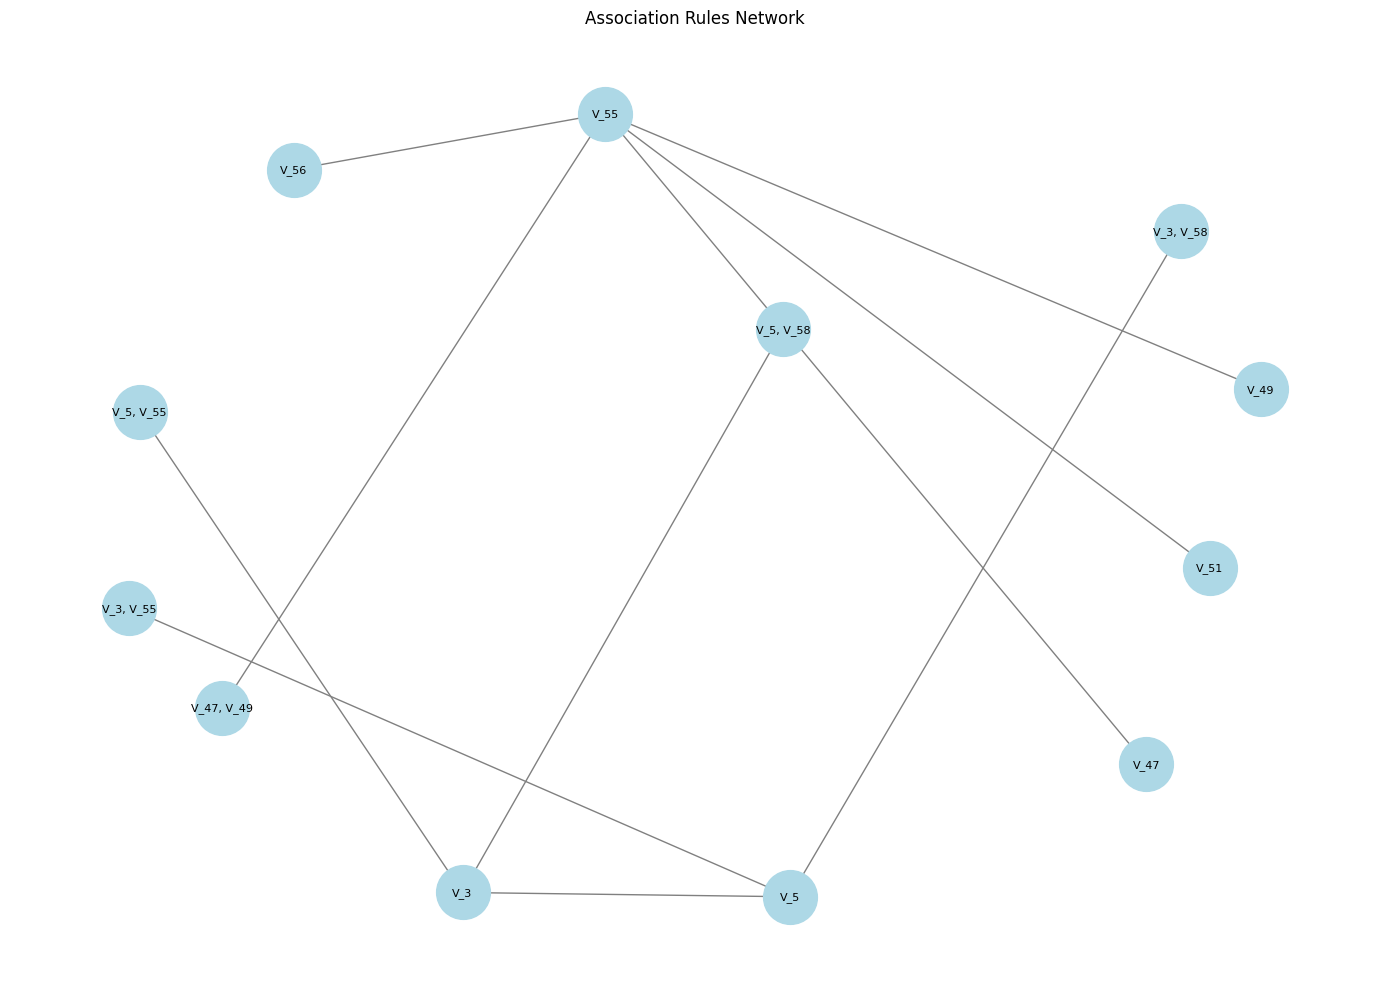

In [1]:
"""
SD6104 Term Project: Association Rule Mining with Apriori Algorithm
Author: Liu Tingxu
Description: Using Apriori algorithm to find association rules in food inspection data
Analysis goal：
1. Find the most common combinations of violation terms
2. Find association rules of Results、Risk、Inspection Type
Requirements: pandas, numpy, matplotlib, seaborn, mlxtend, networkx
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

def load_cleaned_data(file_path='Food_Inspections_Cleaned.csv'):
    """Load the cleaned data"""
    print("=" * 80)
    print("ASSOCIATION RULE MINING - FOOD INSPECTION DATA")
    print("=" * 80)
    
    try:
        df = pd.read_csv(file_path, low_memory=False)
        print(f"✓ Cleaned data loaded: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
        return df
    except FileNotFoundError:
        print(f"✗ Error: File '{file_path}' not found. Please run data cleaning first.")
        exit()
    except Exception as e:
        print(f"✗ Error loading data: {e}")
        exit()

def prepare_violation_transactions(df):
    """
    Prepare transaction data for violation terms analysis
    Target 1: Most frequent violation term combinations
    """
    print("\n" + "-" * 80)
    print("1. PREPARING VIOLATION TERMS TRANSACTIONS")
    print("-" * 80)
    
    # Filter out records with no violations
    violation_df = df[df['Violation Terms'].notna()].copy()
    print(f"Records with violations: {len(violation_df):,} ({len(violation_df)/len(df)*100:.1f}%)")
    
    # Split violation terms into lists
    def split_terms(term_string):
        if pd.isna(term_string):
            return []
        return [f"V_{term.strip()}" for term in str(term_string).split(',')]
    
    violation_df['Violation_Items'] = violation_df['Violation Terms'].apply(split_terms)
    
    # Count unique violation terms
    all_terms = []
    for terms in violation_df['Violation_Items']:
        all_terms.extend(terms)
    
    unique_terms = set(all_terms)
    print(f"Unique violation terms: {len(unique_terms):,}")
    
    # Show most common individual terms
    from collections import Counter
    term_counts = Counter(all_terms)
    print(f"\nTop 10 most frequent individual violation terms:")
    for i, (term, count) in enumerate(term_counts.most_common(10), 1):
        percentage = count / len(violation_df) * 100
        print(f"  {i:2d}. {term:8s}: {count:6,d} ({percentage:5.1f}%)")
    
    # Prepare transactions for Apriori
    transactions = violation_df['Violation_Items'].tolist()
    print(f"Total transactions for violation analysis: {len(transactions):,}")
    
    return transactions, violation_df

def prepare_attribute_transactions(df):
    """
    Prepare transaction data for attribute analysis
    Target 2: Relationships between Results, Risk, Inspection Type
    """
    print("\n" + "-" * 80)
    print("2. PREPARING ATTRIBUTE TRANSACTIONS")
    print("-" * 80)
    
    # Select relevant columns
    attributes = ['Results', 'Risk', 'Inspection Type']
    attribute_df = df[attributes].copy()
    
    # Clean and format attribute values
    def clean_attribute(value, prefix):
        if pd.isna(value):
            return None
        # Remove special characters and add prefix
        cleaned = str(value).replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
        return f"{prefix}_{cleaned}"
    
    # Create transaction items
    transactions = []
    for _, row in attribute_df.iterrows():
        transaction = []
        
        # Add Results
        result_item = clean_attribute(row['Results'], 'RESULT')
        if result_item:
            transaction.append(result_item)
        
        # Add Risk
        risk_item = clean_attribute(row['Risk'], 'RISK')
        if risk_item:
            transaction.append(risk_item)
        
        # Add Inspection Type
        inspection_item = clean_attribute(row['Inspection Type'], 'INSP')
        if inspection_item:
            transaction.append(inspection_item)
        
        transactions.append(transaction)
    
    print(f"Total transactions for attribute analysis: {len(transactions):,}")
    print(f"Sample transaction: {transactions[0]}")
    
    return transactions, attribute_df

def run_apriori_analysis(transactions, analysis_name, min_support=0.01, 
                        min_confidence=0.5, max_itemset_size=4):
    """
    Run Apriori algorithm on transaction data
    """
    print(f"\n" + "-" * 80)
    print(f"APRIORI ANALYSIS: {analysis_name}")
    print("-" * 80)
    print(f"Parameters: min_support={min_support}, min_confidence={min_confidence}")
    
    # Encode transactions
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
    
    print(f"Encoded matrix shape: {df_encoded.shape}")
    print(f"Number of unique items: {len(te.columns_)}")
    
    # Apply Apriori algorithm
    print("\nRunning Apriori algorithm...")
    frequent_itemsets = apriori(
        df_encoded, 
        min_support=min_support, 
        use_colnames=True, 
        max_len=max_itemset_size,  # Make it configurable
        verbose=1
    )
    
    print(f"Found {len(frequent_itemsets)} frequent itemsets")
    
    if len(frequent_itemsets) == 0:
        print("No frequent itemsets found. Try lowering min_support.")
        return None, None
    
    # Show top frequent itemsets
    print(f"\nTop 10 frequent itemsets (by support):")
    top_itemsets = frequent_itemsets.sort_values('support', ascending=False).head(10)
    
    for i, row in enumerate(top_itemsets.itertuples(), 1):
        # Get itemset and support from the row
        itemset = row.itemsets
        support = row.support
        
        # Convert frozenset to sorted list
        itemset_list = sorted(list(itemset))
        itemset_str = ', '.join(itemset_list)
        
        print(f"  {i:2d}. Support: {support:.4f} | Items: {{{itemset_str}}}")
    
    # Generate association rules
    print("\nGenerating association rules...")
    rules = association_rules(
        frequent_itemsets, 
        metric="confidence", 
        min_threshold=min_confidence,
        support_only=False
    )
    
    print(f"Generated {len(rules)} association rules")
    
    if len(rules) > 0:
        # Add additional metrics
        rules['total_length'] = rules['antecedents'].apply(lambda x: len(x)) + rules['consequents'].apply(lambda x: len(x))
        rules['antecedent_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
        rules['consequent_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))
        
        # Sort by lift (most interesting rules first)
        rules = rules.sort_values('lift', ascending=False)
        
        print(f"\nTop 20 rules (by lift):")
        for i, row in rules.head(20).iterrows():
            print(f"  Rule {i+1}: {{{row['antecedent_str']}}} -> {{{row['consequent_str']}}}")
            print(f"     Support: {row['support']:.4f}, Confidence: {row['confidence']:.4f}, "
                  f"Lift: {row['lift']:.4f}, Conviction: {row['conviction']:.4f}")
            print()
    
    return frequent_itemsets, rules

def analyze_violation_patterns(rules, top_n=20):
    """Analyze and visualize violation patterns"""
    if rules is None or len(rules) == 0:
        print("No rules to analyze")
        return
    
    print("\n" + "-" * 80)
    print("VIOLATION PATTERN ANALYSIS")
    print("-" * 80)
    
    # Filter for violation-related rules
    violation_rules = rules[
        rules['antecedents'].apply(lambda x: any('V_' in item for item in x)) |
        rules['consequents'].apply(lambda x: any('V_' in item for item in x))
    ]
    
    print(f"Violation-related rules: {len(violation_rules)}")
    
    if len(violation_rules) == 0:
        return
    
    # Group rules by consequent
    print("\nTop rules grouped by consequent (by lift):")
    violation_rules_sorted = violation_rules.sort_values('lift', ascending=False)
    for consequent in violation_rules_sorted['consequent_str'].unique()[:8]:
        group = violation_rules_sorted[violation_rules_sorted['consequent_str'] == consequent]
        print(f"\nConsequent: {{{consequent}}}")
        for _, row in group.head(2).iterrows():
            print(f"  {{{row['antecedent_str']}}} → {{{row['consequent_str']}}} "
                  f"(conf: {row['confidence']:.3f}, lift: {row['lift']:.3f})")

def analyze_attribute_patterns(rules, top_n=20):
    if rules is None or len(rules) == 0:
        print("No rules to analyze")
        return
    
    print(f"\n" + "-" * 80)
    print("ATTRIBUTE PATTERN ANALYSIS (Results, Risk, Inspection Type)")
    print("-" * 80)
    
    # Rules ending with Results
    result_rules = rules[
        rules['consequents'].apply(lambda x: any('RESULT_' in item for item in x))
    ]
    
    print(f"Rules predicting Results: {len(result_rules)}")
    
    if len(result_rules) > 0:
        print("\nTop rules predicting specific Results:")
        
        for result_type in ['RESULT_Fail', 'RESULT_Pass', 'RESULT_Pass_w_Conditions']:
            result_type_rules = result_rules[
                result_rules['consequents'].apply(
                    lambda x, rt=result_type: rt in x  # Use default parameter for closure
                )
            ]
            
            if len(result_type_rules) > 0:
                print(f"\nRules for {result_type}:")
                for _, row in result_type_rules.head(3).iterrows():
                    print(f"  {{{row['antecedent_str']}}} -> {{{row['consequent_str']}}}")
                    print(f"    Support: {row['support']:.4f}, Confidence: {row['confidence']:.4f}, "
                          f"Lift: {row['lift']:.4f}")
    
    # Rules involving Risk
    risk_rules = rules[
        rules['antecedents'].apply(lambda x: any('RISK_' in item for item in x)) |
        rules['consequents'].apply(lambda x: any('RISK_' in item for item in x))
    ]
    
    print(f"\nRules involving Risk: {len(risk_rules)}")


def visualize_association_rules(rules, top_n=15, metric='lift'):
    """Visualize top association rules"""
    import matplotlib.pyplot as plt
    
    if rules is None or len(rules) == 0:
        return
    
    top_rules = rules.nlargest(top_n, metric).copy()
    top_rules['rule'] = (top_rules['antecedent_str'] + ' → ' + 
                         top_rules['consequent_str'])
    
    fig, ax = plt.subplots(figsize=(12, 8))
    scatter = ax.scatter(top_rules['support'], top_rules['confidence'], 
                        s=top_rules['lift']*100, c=top_rules['lift'], 
                        cmap='viridis', alpha=0.6)
    
    ax.set_xlabel('Support')
    ax.set_ylabel('Confidence')
    ax.set_title(f'Top {top_n} Association Rules (sized by Lift)')
    plt.colorbar(scatter, label='Lift')
    plt.tight_layout()
    plt.show()

def visualize_itemset_network(rules, top_n=10):
    """Create network graph of association rules"""
    if rules is None or len(rules) == 0:
        return
    
    top_rules = rules.nlargest(top_n, 'lift')
    G = nx.DiGraph()
    
    for _, row in top_rules.iterrows():
        antecedent = ', '.join(sorted(row['antecedents']))
        consequent = ', '.join(sorted(row['consequents']))
        G.add_edge(antecedent, consequent, 
                  weight=row['confidence'], 
                  lift=row['lift'])
    
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=2, iterations=50)
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=1500)
    nx.draw_networkx_labels(G, pos, font_size=8)
    nx.draw_networkx_edges(G, pos, edge_color='gray', 
                          arrows=True, arrowsize=20)
    plt.title('Association Rules Network')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def main():
    """Main function to run association rule mining"""
    file_path = 'Food_Inspections_Cleaned.csv'
    # Load cleaned data
    df = load_cleaned_data(file_path)
    
    # Analysis 1: Violation terms combinations
    violation_transactions, violation_df = prepare_violation_transactions(df)
    frequent_itemsets_violation, rules_violation = run_apriori_analysis(
        violation_transactions, 
        "Violation Terms Combinations",
        min_support=0.03,
        min_confidence=0.6
    )
    
    if rules_violation is not None and len(rules_violation) > 0:
        analyze_violation_patterns(rules_violation, top_n=20)
    
    # Analysis 2: Attributes (Results, Risk, Inspection Type)
    attribute_transactions, attribute_df = prepare_attribute_transactions(df)
    frequent_itemsets_attr, rules_attr = run_apriori_analysis(
        attribute_transactions,
        "Attribute Relationships (Results, Risk, Inspection Type)",
        min_support=0.02, 
        min_confidence=0.6
    )
    
    if rules_attr is not None and len(rules_attr) > 0:
        analyze_attribute_patterns(rules_attr, top_n=20)

    if rules_violation is not None and len(rules_violation) > 0:
        analyze_violation_patterns(rules_violation)
        visualize_association_rules(rules_violation, top_n=15, metric='lift')
        visualize_itemset_network(rules_violation, top_n=10)
    
    return {
        'violation_rules': rules_violation,
        'attribute_rules': rules_attr,
        'violation_df': violation_df,
        'attribute_df': attribute_df
    }

if __name__ == "__main__":
    results = main()
